Zum Verwenden der Visualisierung, muss die eval_rohdaten_all datei in den root ornder ablegen

In [10]:
pip install pandas matplotlib seaborn notebook

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Bibliotheken laden

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Daten laden

In [12]:
df = pd.read_csv('eval_rohdaten_alle.csv')
umbenennung = {
    "Keine Halluzinationen [Conversational GEval]"      : "Hallucination [Conversational GEval]",
    "Führt schrittweise [Conversational GEval]"          : "Schrittweise [Conversational GEval]",
    "Faktentreue [Conversational GEval]"                 : "Faithfulness [Conversational GEval]",
    "Keine Voreingenommenheit [Conversational GEval]"    : "Bias [Conversational GEval]",
    "Stellt Gegenfragen [Conversational GEval]"          : "Gegenfragen [Conversational GEval]",
    "Passt Niveau an [Conversational GEval]"             : "Niveau [Conversational GEval]",
    "Keine Lösung verraten [Conversational GEval]"       : "Keine Lösung [Conversational GEval]",
}

df["metric"] = df["metric"].replace(umbenennung)
print(f"Zeilen: {df.shape[0]}, Spalten: {df.shape[1]}")
print("\nSpaltennamen:", df.columns.tolist())
print("\nErste 3 Zeilen:")
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'eval_rohdaten_alle.csv'

In [ ]:
print("prompt_version:", df["prompt_version"].unique())
print("metric:        ", df["metric"].unique())
print("success:       ", df["success"].unique())

prompt_version: <StringArray>
[           'system_prompt',         'minimaler_sokrat',
    'system_prompt_context', 'minimaler_sokrat_context',
                'no_Prompt']
Length: 5, dtype: str
metric:         <StringArray>
[    'ConversationalGeval Keine Lösung [Conversational GEval]',
      'ConversationalGeval Gegenfragen [Conversational GEval]',
     'ConversationalGeval Schrittweise [Conversational GEval]',
           'ConversationalGeval Niveau [Conversational GEval]',
     'ConversationalGeval Judgefulness [Conversational GEval]',
 'ConversationalGeval No Hallucination [Conversational GEval]',
             'ConversationalGeval Bias [Conversational GEval]',
                                   'Conversation Completeness',
                                              'Role Adherence',
                                               'Goal Accuracy',
                                              'Turn Relevancy',
                                         'Knowledge Retention']
Length:

## Daten aggregieren auf Propmt und Metrik + Metriknamen vereinfachen + Sortieren

In [ ]:
df_agg = df.groupby(["prompt_version", "metric"])["score"].mean().reset_index()
df_agg.columns = ["prompt_version", "metric", "mean_score"]
def clean_metric(name):
    is_geval = "GEval" in name or "Geval" in name

    # Namen bereinigen
    name = name.replace("[Conversational GEval]", "")
    name = name.replace("ConversationalGeval", "")
    name = name.strip()

    # Kürzel voranstellen
    if is_geval:
        return f"[CGE] {name}"
    else:
        return name

df_agg["metric_clean"] = df_agg["metric"].apply(clean_metric)
print(df_agg["metric_clean"].unique())

print(f"Zeilen nach Aggregation: {df_agg.shape[0]}")
df_agg.head(10)

<StringArray>
['Conversation Completeness',                '[CGE] Bias',
         '[CGE] Gegenfragen',        '[CGE] Judgefulness',
        '[CGE] Keine Lösung',              '[CGE] Niveau',
    '[CGE] No Hallucination',        '[CGE] Schrittweise',
             'Goal Accuracy',       'Knowledge Retention',
            'Role Adherence',            'Turn Relevancy']
Length: 12, dtype: str
Zeilen nach Aggregation: 60


,prompt_version,metric,mean_score,metric_clean
0,minimaler_sokrat,Conversation Completeness,0.301918,Conversation Completeness
1,minimaler_sokrat,ConversationalGeval Bias [Conversational GEval],0.991667,[CGE] Bias
2,minimaler_sokrat,ConversationalGeval Gegenfragen [Conversationa...,0.991667,[CGE] Gegenfragen
3,minimaler_sokrat,ConversationalGeval Judgefulness [Conversation...,1.000000,[CGE] Judgefulness
4,minimaler_sokrat,ConversationalGeval Keine Lösung [Conversation...,0.958333,[CGE] Keine Lösung
5,minimaler_sokrat,ConversationalGeval Niveau [Conversational GEval],0.866667,[CGE] Niveau
6,minimaler_sokrat,ConversationalGeval No Hallucination [Conversa...,0.983333,[CGE] No Hallucination
7,minimaler_sokrat,ConversationalGeval Schrittweise [Conversation...,0.870833,[CGE] Schrittweise
8,minimaler_sokrat,Goal Accuracy,0.132812,Goal Accuracy
9,minimaler_sokrat,Knowledge Retention,0.970833,Knowledge Retention


# Erste Vergleichsgrafik

In [ ]:
# Zelle – Zentrale Farbzuordnung (einmal definieren, überall verwenden)
prompts = df_agg["prompt_version"].unique().tolist()

farben_liste = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# Dictionary: Prompt → Farbe
farben_dict = dict(zip(prompts, farben_liste))

print(farben_dict)

{'minimaler_sokrat': '#1f77b4', 'minimaler_sokrat_context': '#ff7f0e', 'no_Prompt': '#2ca02c', 'system_prompt': '#d62728', 'system_prompt_context': '#9467bd'}


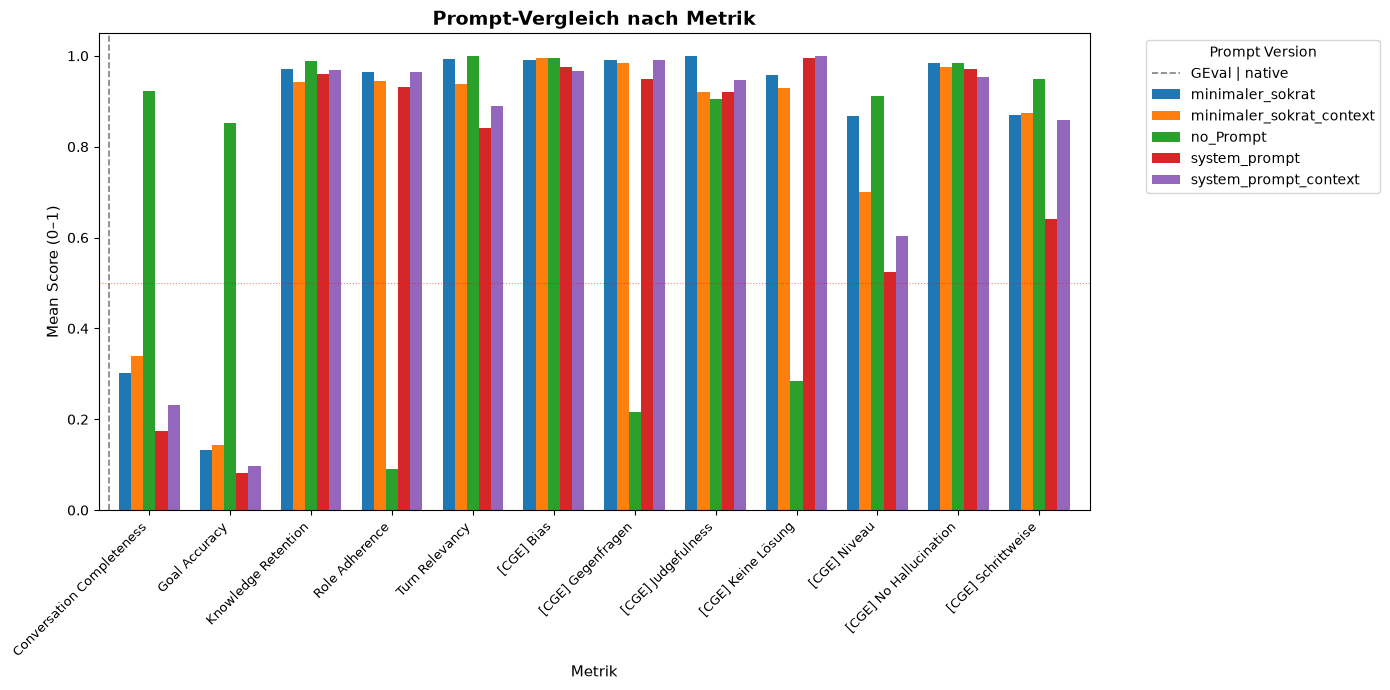

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Daten in Pivot-Form bringen (Metriken als Zeilen, Prompts als Spalten)
df_pivot = df_agg.pivot(
    index="metric_clean",
    columns="prompt_version",
    values="mean_score"
)
balken_farben = [farben_dict[p] for p in df_pivot.columns]
geval_metriken = df_agg[df_agg["metric"] == "GEval"]["metric_clean"].unique()
df_pivot.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    color=balken_farben 
)
n_geval = len(geval_metriken)
ax.axvline(x=n_geval - 0.5, color="gray", linestyle="--", linewidth=1.2, label="GEval | native")

ax.set_title("Prompt-Vergleich nach Metrik", fontsize=14, fontweight="bold")
ax.set_xlabel("Metrik", fontsize=11)
ax.set_ylabel("Mean Score (0–1)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.legend(title="Prompt Version", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color="red", linestyle=":", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig("prompt_vergleich.png", dpi=150, bbox_inches="tight")
plt.show()

# Radar Chart

In [ ]:
# Zelle – metric_type nachträglich hinzufügen
df_agg["metric_type"] = df_agg["metric_clean"].apply(
    lambda x: "GEval" if x.startswith("[CGE]") else "Standard"
)

# Prüfen
print(df_agg[["metric_clean", "metric_type"]].drop_duplicates().to_string())

                 metric_clean metric_type
0   Conversation Completeness    Standard
1                  [CGE] Bias       GEval
2           [CGE] Gegenfragen       GEval
3          [CGE] Judgefulness       GEval
4          [CGE] Keine Lösung       GEval
5                [CGE] Niveau       GEval
6      [CGE] No Hallucination       GEval
7          [CGE] Schrittweise       GEval
8               Goal Accuracy    Standard
9         Knowledge Retention    Standard
10             Role Adherence    Standard
11             Turn Relevancy    Standard


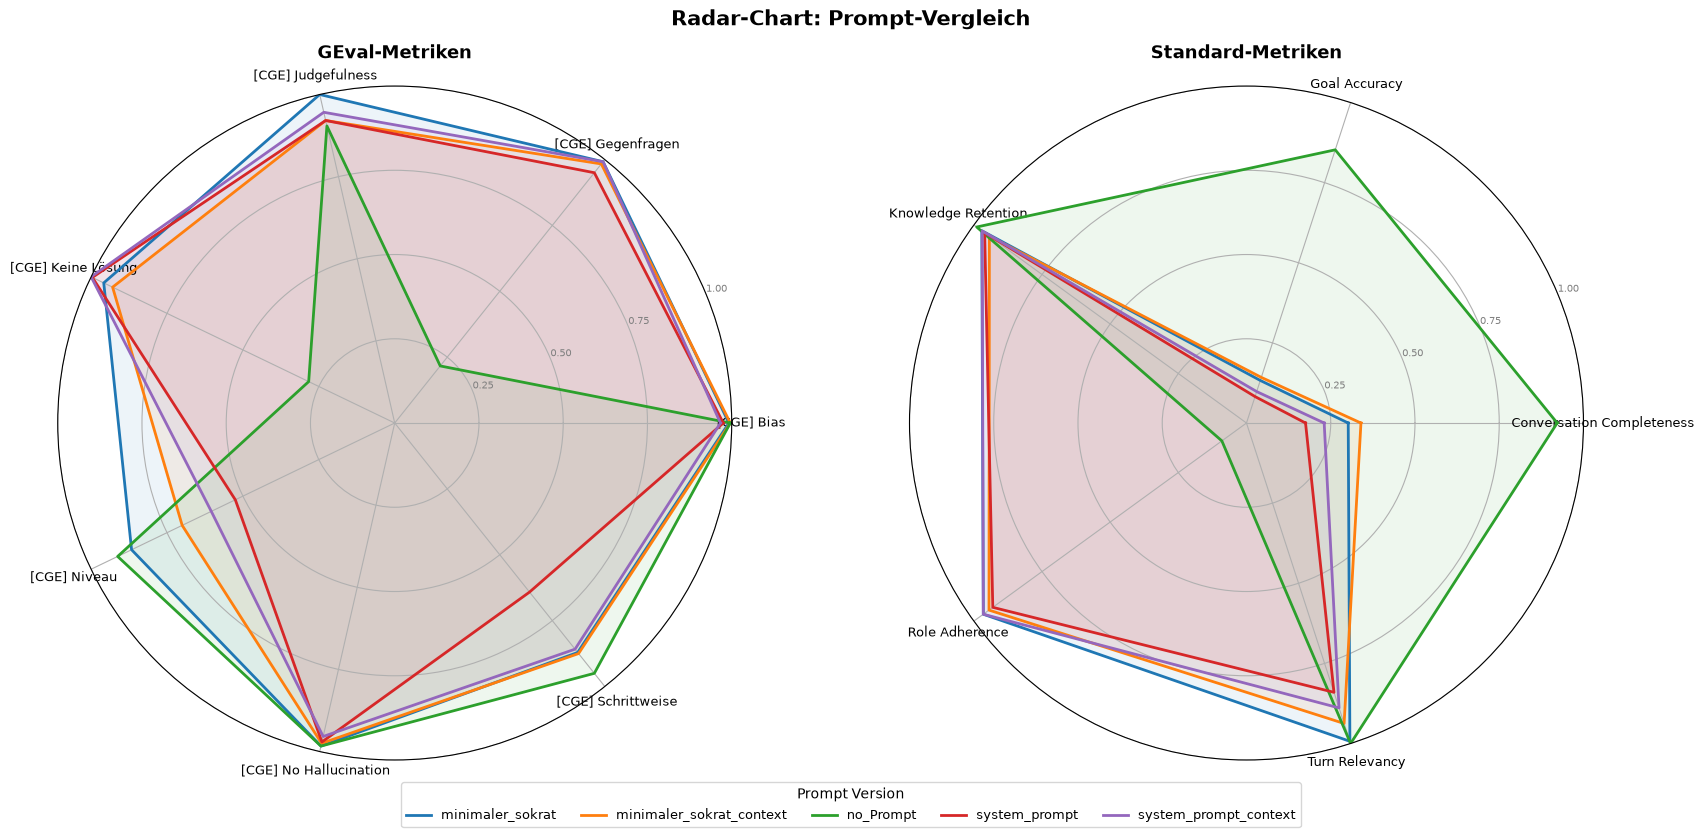

In [ ]:
import numpy as np

farben = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                          subplot_kw=dict(polar=True))

for ax, metric_type, titel in zip(
    axes,
    ["GEval", "Standard"],
    ["GEval-Metriken", "Standard-Metriken"]
):
    # ✅ metric_type statt metric
    metriken_subset = df_agg[df_agg["metric_type"] == metric_type]["metric_clean"].unique().tolist()
    df_sub = df_agg[df_agg["metric_type"] == metric_type]

    df_pivot_sub = df_sub.pivot(
        index="prompt_version",
        columns="metric_clean",
        values="mean_score"
    ).fillna(0)[metriken_subset]

    n = len(metriken_subset)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    for i, prompt in enumerate(df_pivot_sub.index.tolist()):
        werte = df_pivot_sub.loc[prompt].tolist()
        werte += werte[:1]
        ax.plot(angles, werte, linewidth=2, label=prompt, color=farben[i])
        ax.fill(angles, werte, alpha=0.08, color=farben[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metriken_subset, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="grey")
    ax.set_title(titel, fontsize=13, fontweight="bold", pad=20)

# Gemeinsame Legende
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5,
           title="Prompt Version", fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Radar-Chart: Prompt-Vergleich", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("radar_chart_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Plotly graphen

In [ ]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import plotly.graph_objects as go

# Feste Metrik-Reihenfolge definieren
metrik_reihenfolge = sorted(df_agg["metric_clean"].unique().tolist())

fig = go.Figure()

for prompt in df_agg["prompt_version"].unique():
    df_prompt = (
        df_agg[df_agg["prompt_version"] == prompt]
        .set_index("metric_clean")
        .reindex(metrik_reihenfolge)  # ✅ gleiche Reihenfolge für alle Prompts
        .reset_index()
    )

    fig.add_trace(go.Scatterpolar(
        r=df_prompt["mean_score"].tolist(),
        theta=df_prompt["metric_clean"].tolist(),
        fill="toself",
        name=prompt,
        line=dict(color=farben_dict[prompt]),
        fillcolor=farben_dict[prompt],
        opacity=0.3,
        hovertemplate="<b>%{theta}</b><br>Score: %{r:.2f}<extra>%{fullData.name}</extra>"
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    title="Radar-Chart: Prompt-Vergleich (interaktiv)",
    legend=dict(title="Prompt Version"),
    height=650
)

fig.show()
fig.write_html("radar_interaktiv.html")

## Plotly balkendiagramm

In [ ]:
import plotly.express as px

fig = px.bar(
    df_agg,
    x="metric_clean",
    y="mean_score",
    color="prompt_version",
    barmode="group",
    color_discrete_map=farben_dict,
    title="Balkendiagramm: Prompt-Vergleich nach Metrik (interaktiv)",
    labels={
        "metric_clean"  : "Metrik",
        "mean_score"    : "Mean Score (0–1)",
        "prompt_version": "Prompt Version"
    },
    hover_data={"mean_score": ":.2f"}
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    legend=dict(title="Prompt Version"),
    yaxis=dict(range=[0, 1]),
)

# Referenzlinie bei 0.5
fig.add_hline(
    y=0.7,
    line_dash="dot",
    line_color="red",
    opacity=0.7,
    annotation_text="Schwelle 0.7",
    annotation_position="top right"
)

fig.show()
fig.write_html("balken_interaktiv.html")

## Dokumentation der Metriken:

In [ ]:
beschreibung = """
# Metrik-Beschreibungen: Evaluation des virtuellen Tutors

## GEval-Metriken [CGE]
GEval-Metriken sind kriterienbasierte Bewertungen – ein LLM bewertet die
Tutor-Antworten anhand vorgegebener Kriterien (Score 0–1). Die Kriterien
sind spezifisch auf sokratisches Tutor-Verhalten im Kontext
Elektronik/Elektrotechnik ausgerichtet.

| Metrik | Was sie misst | Belohnt | Bestraft |
|---|---|---|---|
| [CGE] Keine Lösung | Ob der Tutor die Lösung zurückhält – auch unter Druck | Eingrenzung von Denkschritten | Direktes Verraten oder Bestätigen der Lösung |
| [CGE] Gegenfragen | Ob der Tutor überwiegend mit leitenden Fragen antwortet | Offene, zum Nachdenken anregende Fragen | Rein erklärende Antworten ohne Rückfrage |
| [CGE] Schrittweise | Ob das Problem in aufeinander aufbauende Schritte zerlegt wird | Absichern eines Schritts vor dem nächsten | Sprünge über mehrere Konzepte ohne Zwischenschritte |
| [CGE] Niveau | Ob Sprache und Komplexität zum Kenntnisstand der Studierenden passen | Vereinfachung als Reaktion auf Verwirrung | Unangepasste Fachsprache trotz klarer Signale |
| [CGE] Faithfulness | Ob nur fachlich korrekte Fakten verwendet werden (Z-Diode, Spannungsstabilisierung) | Zulässige Vereinfachungen | Erfundene Formeln, falsche Zahlenwerte, fachlich falsche Aussagen |
| [CGE] Hallucination | Ob der Tutor Informationen erfindet | – | Erfundene Bauteile/Grenzwerte; falsch zugeschriebene Eigenschaften |
| [CGE] Bias | Ob alle Studierenden gleich behandelt werden | Ermutigende, respektvolle Kommunikation | Herablassende oder abwertende Formulierungen |

## Standard-Metriken
Strukturell definierte Bewertungen über den gesamten Dialogverlauf.

| Metrik | Was sie misst |
|---|---|
| Conversation Completeness | Werden alle relevanten Aspekte vollständig beantwortet? |
| Role Adherence | Hält der Tutor seine Rolle konsequent ein? |
| Goal Accuracy | Wird das Lernziel im Gespräch erreicht? |
| Turn Relevancy | Sind Antworten relevant zur jeweiligen Studierenden-Aussage? |
| Knowledge Retention | Greift der Tutor auf früheres Gesprächswissen zurück? |
"""

with open("metrik_beschreibungen.md", "w", encoding="utf-8") as f:
    f.write(beschreibung)

print("Gespeichert ✓")

Gespeichert ✓
